# Real Estate Market Insights: Exploratory Analysis of Zameen.com Listings
**AtomCamp | Data Analytics Project**

## 1. Problem Statement

Pakistan's real estate market is large but poorly transparent for retail investors.
Zameen.com is the country's leading property portal with hundreds of thousands of listings.

**Business Question:** *What drives property prices in Pakistan — and how do prices vary across cities, property types, and sizes?*

**Goals:**
- Understand the distribution of property types, prices, and area sizes
- Compare pricing across major cities
- Identify which features correlate most with price
- Provide actionable recommendations for real estate investors

## 2. Data Understanding & Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Global chart style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13, 'axes.labelsize': 11})

In [2]:
# Load only the required columns — as specified in the project brief
COLS = ['City', 'Location', 'Price', 'Type', 'Area', 'Purpose', 'Bedrooms', 'Bathrooms']

df = pd.read_csv('Zameen_Data.csv', usecols=COLS)

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Shape: (18255, 8)
Columns: ['City', 'Type', 'Area', 'Price', 'Purpose', 'Location', 'Bedrooms', 'Bathrooms']


,City,Type,Area,Price,Purpose,Location,Bedrooms,Bathrooms
0,Karachi,Flat,128 Sq. Yd.,PKR\n4.75 Crore,For Sale,"DHA Defence, Karachi, Sindh",2,2
1,Karachi,Flat,161 Sq. Yd.,PKR\n6.25 Crore,For Sale,"DHA Defence, Karachi, Sindh",2,3
2,Karachi,Flat,111 Sq. Yd.,PKR\n3.45 Crore,For Sale,"DHA Defence, Karachi, Sindh",1,2
3,Karachi,Flat,106 Sq. Yd.,PKR\n2.98 Crore,For Sale,"DHA Defence, Karachi, Sindh",1,2
4,Karachi,Flat,156 Sq. Yd.,PKR\n4.65 Crore,For Sale,"DHA Defence, Karachi, Sindh",2,2


In [3]:
# Basic dataset info — dtypes, non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18255 entries, 0 to 18254
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   City       18255 non-null  object
 1   Type       18239 non-null  object
 2   Area       18239 non-null  object
 3   Price      18239 non-null  object
 4   Purpose    18239 non-null  object
 5   Location   18239 non-null  object
 6   Bedrooms   18239 non-null  object
 7   Bathrooms  18239 non-null  object
dtypes: object(8)
memory usage: 1.1+ MB


In [4]:
# Statistical summary — check for suspicious min/max values in Price, Area, Bedrooms
df.describe(include='all')

,City,Type,Area,Price,Purpose,Location,Bedrooms,Bathrooms
count,18255,18239,18239,18239,18239,18239,18239,18239
unique,84,7,468,1022,2,1051,12,10
top,Karachi,House,5 Marla,PKR\n60 Thousand,For Sale,"Bahria Town Rawalpindi, Rawalpindi, Punjab",5,6
freq,1250,13386,3528,269,11126,1884,4174,4993


### Observations from `.describe()`
- **Price** will be heavily right-skewed — a few luxury listings will have very high max values.
- **Bedrooms / Bathrooms** — check for zeros which may be data entry errors.
- Categorical columns — `unique` and `top` reveal dominant categories.

In [5]:
# Remove exact duplicate rows
print(f"Duplicate rows: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Shape after removing duplicates: {df.shape}")

Duplicate rows: 3826
Shape after removing duplicates: (14429, 8)


## 3. Missing Values Treatment

In [6]:
# Count missing values per column
missing = df.isnull().sum().sort_values(ascending=False)
print("Missing values per column:")
print(missing)
print(f"\nTotal missing: {missing.sum()}")

Missing values per column:
Type         8
Area         8
Price        8
Purpose      8
Bedrooms     8
Location     8
Bathrooms    8
City         0
dtype: int64

Total missing: 56


In [7]:
# --- Impute missing values ---

# Categorical columns → mode (most frequent value)
for col in ['City', 'Location', 'Type', 'Purpose']:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f"  '{col}' filled with mode: '{mode_val}'")

# Discrete count columns → median (avoids non-integer values like 2.3 bedrooms)
for col in ['Bedrooms', 'Bathrooms']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    if df[col].isnull().sum() > 0:
        med = df[col].median()
        df[col] = df[col].fillna(med)
        print(f"  '{col}' filled with median: {med}")

print(f"\nMissing values after imputation: {df.isnull().sum().sum()}")

  'Location' filled with mode: 'Bahria Town Rawalpindi, Rawalpindi, Punjab'
  'Type' filled with mode: 'House'
  'Purpose' filled with mode: 'For Sale'
  'Bedrooms' filled with median: 4.0
  'Bathrooms' filled with median: 4.0

Missing values after imputation: 16


### Justification

| Column | Strategy | Why |
|---|---|---|
| City, Type, Purpose, Location | **Mode** | Most frequent category — not applicable to use mean/median on strings |
| Bedrooms, Bathrooms | **Median** | Avoids producing non-integer values (e.g. 2.3 bedrooms). Robust to skew |
| Price, Area | Handled next via cleaning | Need unit parsing before imputation |

## 4. Data Cleaning & Consistency

In [8]:
!pip install fuzzywuzzy python-levenshtein -q

In [9]:
import re
from fuzzywuzzy import process


# ── 1. Standardize city names using FuzzyWuzzy ──
STANDARD_CITIES = ['Karachi', 'Lahore', 'Islamabad', 'Rawalpindi', 'Faisalabad', 'Multan']

def standardize_city(name):
    """Match any city name variant to the nearest standard city name."""
    if pd.isna(name):
        return 'Karachi'  # default to mode
    match, score = process.extractOne(str(name), STANDARD_CITIES)
    return match  # always return the best match

df['City'] = df['City'].apply(standardize_city)
print("✔ City names standardized")
print(df['City'].value_counts())

✔ City names standardized
City
Islamabad     3660
Rawalpindi    2883
Karachi       2530
Lahore        2254
Faisalabad    1741
Multan        1361
Name: count, dtype: int64


In [10]:
# ── 2. Parse Price column: remove PKR/commas, convert Lakh/Crore/Arab to numeric PKR ──

def parse_price(val):
    """Convert price strings like '1.5 Crore PKR' to a float in PKR."""
    if pd.isna(val):
        return np.nan
    s = re.sub(r'PKR|\n|,|\s+', '', str(val))
    units = {'Arab': 1e9, 'Crore': 1e7, 'Lakh': 1e5, 'Thousand': 1e3}
    for unit, factor in units.items():
        if unit in s:
            try:
                return float(s.replace(unit, '')) * factor
            except ValueError:
                return np.nan
    try:
        return float(s)
    except ValueError:
        return np.nan

df['Price'] = df['Price'].apply(parse_price)
print("✔ Price parsed to numeric PKR")
print(df['Price'].describe())

✔ Price parsed to numeric PKR
count    1.442100e+04
mean     3.221876e+07
std      8.194683e+07
min      6.000000e+03
25%      1.400000e+05
50%      1.370000e+07
75%      3.500000e+07
max      1.800000e+09
Name: Price, dtype: float64


In [11]:
# ── 3. Convert Area to uniform sqft ──

def convert_area_to_sqft(val):
    """Convert Marla/Kanal/Sq.Yd area strings to sqft (float)."""
    if pd.isna(val):
        return np.nan
    s = str(val).lower().strip()
    conversions = {'marla': 272.25, 'kanal': 5445.0, 'sq. yd': 9.0, 'sqft': 1.0}
    match = re.match(r'([\d.]+)\s*(.*)', s)
    if match:
        num = float(match.group(1))
        unit = match.group(2).strip()
        for key, factor in conversions.items():
            if key in unit:
                return num * factor
        return num  # assume sqft if no unit found
    return np.nan

df['Area'] = df['Area'].apply(convert_area_to_sqft)
print("✔ Area converted to sqft")
print(df['Area'].describe())

✔ Area converted to sqft
count     14421.000000
mean       3252.829774
std       11733.793011
min           0.000000
25%        1361.250000
50%        2160.000000
75%        3267.000000
max      816750.000000
Name: Area, dtype: float64


In [12]:
# ── 4. Standardize Purpose column using FuzzyWuzzy ──

def clean_purpose(val):
    """Map any purpose variant to 'For Sale' or 'For Rent'."""
    valid = ['For Sale', 'For Rent']
    if pd.isna(val):
        return 'For Sale'
    match, score = process.extractOne(str(val).strip(), valid)
    return match if score >= 60 else 'For Sale'

df['Purpose'] = df['Purpose'].apply(clean_purpose)
print("✔ Purpose standardized")
print(df['Purpose'].value_counts())

✔ Purpose standardized
Purpose
For Sale    14429
Name: count, dtype: int64


In [13]:
# ── 5. Detect and cap price outliers using IQR method ──
# IQR is data-driven — threshold comes from the data itself, not a hardcoded number.

df.dropna(subset=['Price', 'Area'], inplace=True)  # Drop rows where price/area still missing

Q1  = df['Price'].quantile(0.25)
Q3  = df['Price'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 3.0 * IQR

outliers = (df['Price'] > upper_fence).sum()
print(f"  IQR upper fence: PKR {upper_fence:,.0f}")
print(f"  Outlier rows: {outliers} ({outliers/len(df)*100:.1f}%)")

df['Price'] = df['Price'].clip(upper=upper_fence)  # Cap — don't drop
print(f"\nFinal shape after cleaning: {df.shape}")

  IQR upper fence: PKR 139,580,000
  Outlier rows: 567 (3.9%)

Final shape after cleaning: (14421, 8)


## 5. Feature Engineering

In [14]:
# 1. Price per sqft — fair price comparison across different property sizes
df['Price_per_sqft'] = df['Price'] / df['Area']

# 2. Log Price — used in distributions to handle extreme right skew
df['Log_Price'] = np.log1p(df['Price'])

# 3. Bedroom category — cleaner labels for visualisation
def bed_category(v):
    if pd.isna(v) or v <= 1: return 'Studio/1-Bed'
    if v == 2:               return '2-Bed'
    if v == 3:               return '3-Bed'
    return '4+-Bed'

df['Bedroom_cat'] = df['Bedrooms'].apply(bed_category)

# 4. Area size category — groups properties by scale
df['Area_cat'] = pd.cut(df['Area'],
                         bins=[0, 500, 1500, 3500, np.inf],
                         labels=['Compact', 'Standard', 'Large', 'Estate'])

print("New features created:")
print(df[['Price', 'Price_per_sqft', 'Log_Price', 'Bedroom_cat', 'Area_cat']].head())

New features created:
        Price  Price_per_sqft  Log_Price   Bedroom_cat  Area_cat
0  47500000.0    41232.638889  17.676240         2-Bed  Standard
1  62500000.0    43133.195307  17.950677         2-Bed  Standard
2  34500000.0    34534.534535  17.356470  Studio/1-Bed  Standard
3  29800000.0    31236.897275  17.210019  Studio/1-Bed  Standard
4  46500000.0    33119.658120  17.654963         2-Bed  Standard


## 6. Univariate & Bivariate Analysis

### 6.1 Price Distribution (Raw vs Log)

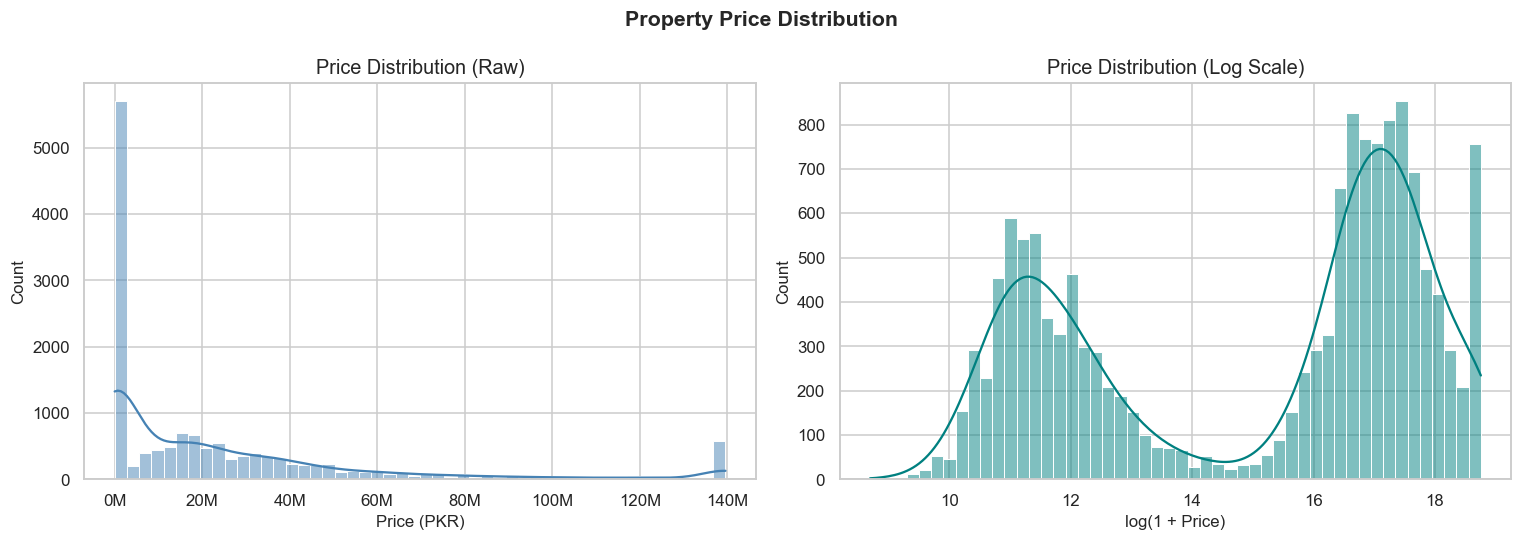

In [15]:
# Chart 1: Price Distribution — Raw vs Log
# Raw prices are always right-skewed on property data. The log-transformed version
# reveals the true underlying bell-shaped (log-normal) distribution.

plot_df = df.dropna(subset=['Price', 'Area', 'City', 'Type', 'Purpose']).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw price — shows the heavy skew
sns.histplot(plot_df['Price'], bins=50, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Price Distribution (Raw)')
axes[0].set_xlabel('Price (PKR)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

# Right: log price — reveals the true shape
sns.histplot(plot_df['Log_Price'], bins=50, kde=True, color='teal', ax=axes[1])
axes[1].set_title('Price Distribution (Log Scale)')
axes[1].set_xlabel('log(1 + Price)')

plt.suptitle('Property Price Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.2 Property Type & City — Listing Counts

C:\Users\Faizan\AppData\Local\Temp\ipykernel_4964\1860155378.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=plot_df[plot_df['Type'].isin(type_order)],
C:\Users\Faizan\AppData\Local\Temp\ipykernel_4964\1860155378.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=plot_df, y='City', order=city_order, palette='magma', ax=axes[1])


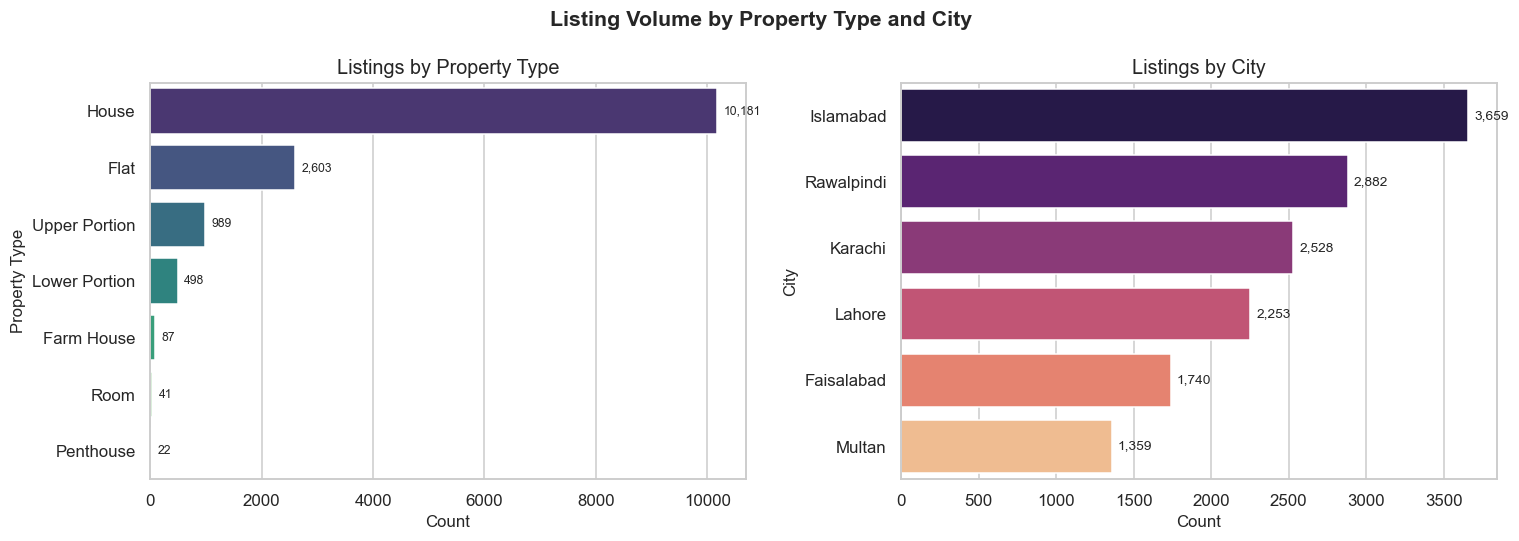

In [16]:
# Chart 2: Listing counts by Property Type and City
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Property Type
type_order = plot_df['Type'].value_counts().nlargest(8).index
sns.countplot(data=plot_df[plot_df['Type'].isin(type_order)],
              y='Type', order=type_order, palette='viridis', ax=axes[0])
axes[0].set_title('Listings by Property Type')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Property Type')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_width()):,}',
                     xy=(p.get_width(), p.get_y() + p.get_height()/2),
                     xytext=(4, 0), textcoords='offset points', va='center', fontsize=8)

# Right: City
city_order = plot_df['City'].value_counts().index
sns.countplot(data=plot_df, y='City', order=city_order, palette='magma', ax=axes[1])
axes[1].set_title('Listings by City')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('City')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_width()):,}',
                     xy=(p.get_width(), p.get_y() + p.get_height()/2),
                     xytext=(4, 0), textcoords='offset points', va='center', fontsize=9)

plt.suptitle('Listing Volume by Property Type and City', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.3 Median Price by City

C:\Users\Faizan\AppData\Local\Temp\ipykernel_4964\1659093597.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=city_med, x='City', y='Price', palette='Blues_r', ax=ax)


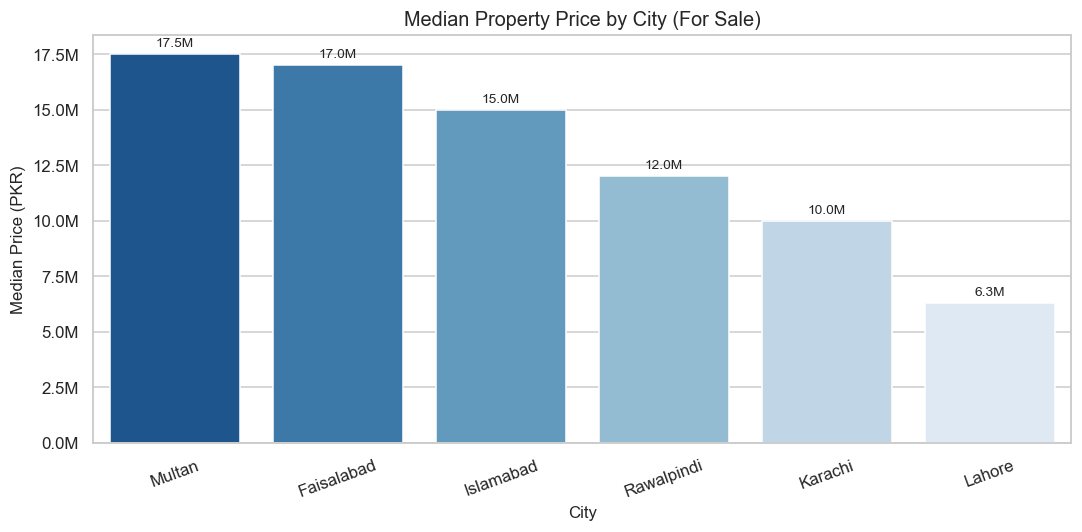

In [17]:
# Chart 3: Median Price by City (For Sale only)
# For Sale and For Rent prices are on completely different scales.
# Mixing them makes the median meaningless, so we filter to For Sale.

sale_df = plot_df[plot_df['Purpose'] == 'For Sale']

city_med = (sale_df.groupby('City')['Price']
                   .median()
                   .sort_values(ascending=False)
                   .reset_index())

fig, ax = plt.subplots(figsize=(10, 5))
bars = sns.barplot(data=city_med, x='City', y='Price', palette='Blues_r', ax=ax)
ax.set_title('Median Property Price by City (For Sale)', fontsize=13)
ax.set_xlabel('City')
ax.set_ylabel('Median Price (PKR)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.tick_params(axis='x', rotation=20)

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()/1e6:.1f}M',
                xy=(p.get_x() + p.get_width()/2, p.get_height()),
                xytext=(0, 5), textcoords='offset points', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

### 6.4 Price per Sqft by City

C:\Users\Faizan\AppData\Local\Temp\ipykernel_4964\2123968378.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sale_df.dropna(subset=['Price_per_sqft']),


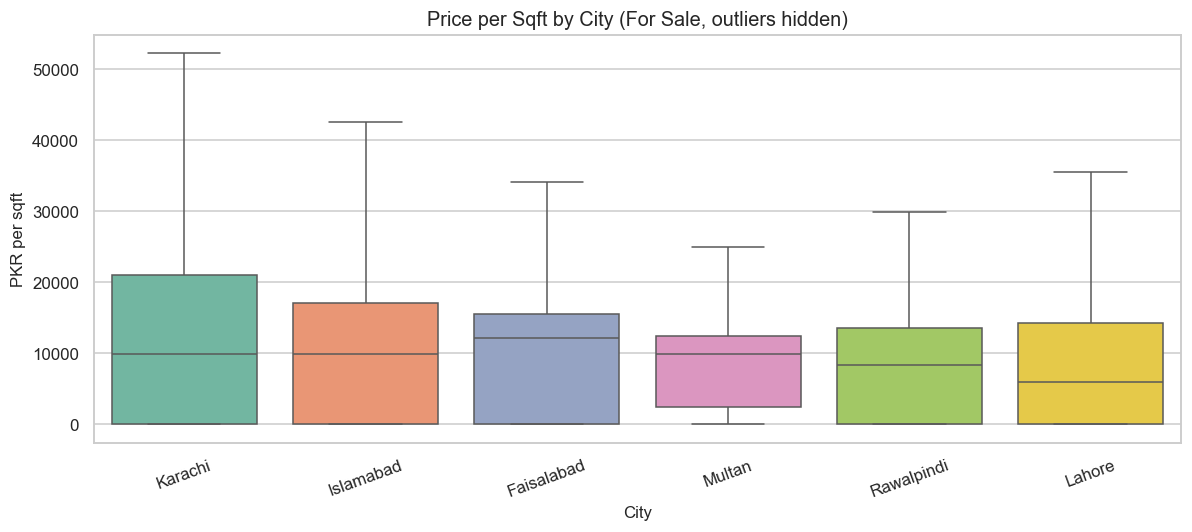

In [18]:
# Chart 4: Price per Sqft by City — Box Plot
# Total price is biased by property size. Price-per-sqft is a fairer city comparison
# because it normalises for how large each property is.
# Log scale is used on Y-axis because a few luxury listings stretch the axis enormously.

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=sale_df.dropna(subset=['Price_per_sqft']),
            x='City', y='Price_per_sqft',
            palette='Set2', showfliers=False, ax=ax)

ax.set_title('Price per Sqft by City (For Sale, outliers hidden)', fontsize=13)
ax.set_xlabel('City')
ax.set_ylabel('PKR per sqft')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

### 6.5 Price Distribution by Property Type — Violin Plot

C:\Users\Faizan\AppData\Local\Temp\ipykernel_4964\27214683.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=violin_df, x='Type', y='Log_Price',


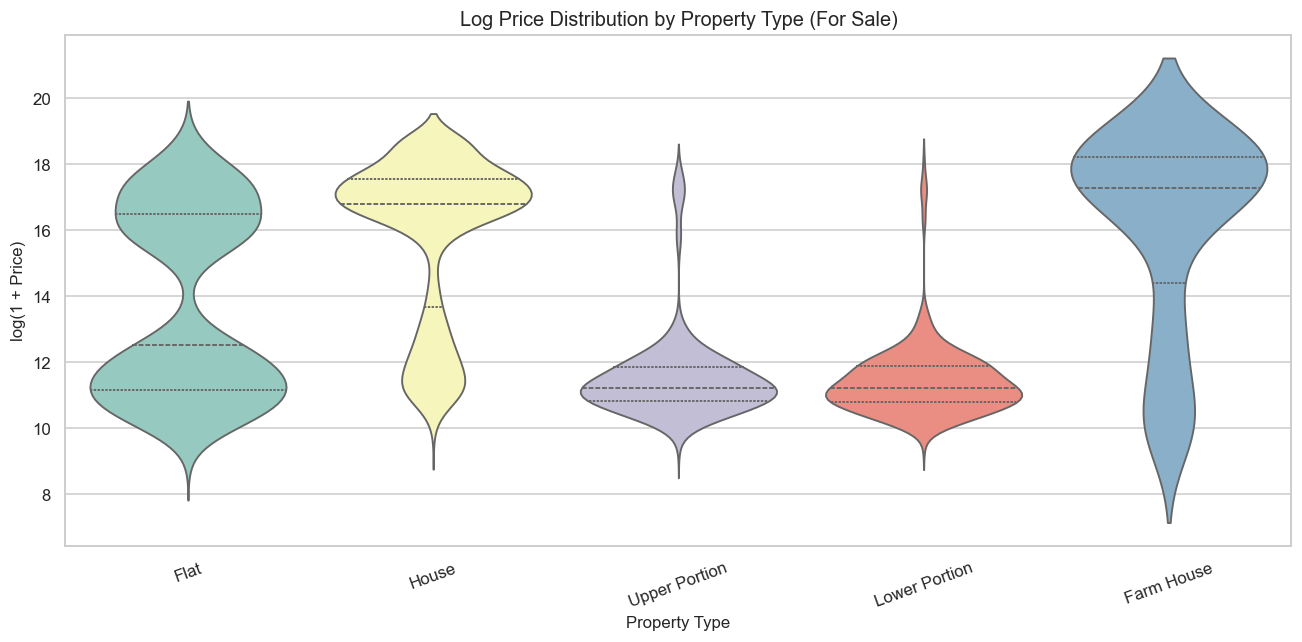

Dashed lines inside violins = Q1, Median, Q3


In [19]:
# Chart 5: Price Distribution by Property Type — Violin Plot
# Violin plots show both the median AND the full shape of the distribution.
# inner='quartile' draws the median and Q1/Q3 lines inside the violin.
# We use Log_Price because raw price violins would be unreadable (thin spikes).

top_types = sale_df['Type'].value_counts().nlargest(5).index
violin_df = sale_df[sale_df['Type'].isin(top_types)].dropna(subset=['Log_Price'])

fig, ax = plt.subplots(figsize=(12, 6))
sns.violinplot(data=violin_df, x='Type', y='Log_Price',
               palette='Set3', inner='quartile', ax=ax)
ax.set_title('Log Price Distribution by Property Type (For Sale)', fontsize=13)
ax.set_xlabel('Property Type')
ax.set_ylabel('log(1 + Price)')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()
print("Dashed lines inside violins = Q1, Median, Q3")

### 6.6 Price by Bedroom Category — Box Plot

C:\Users\Faizan\AppData\Local\Temp\ipykernel_4964\3018282022.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=bed_df, x='Bedroom_cat', y='Price',


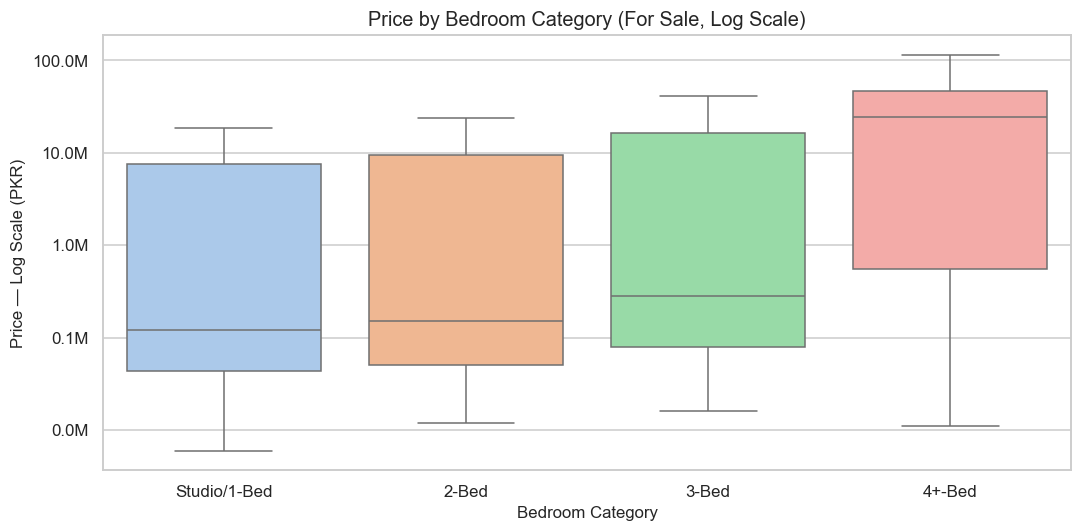

In [20]:
# Chart 6: Price by Bedroom Category
# Shows how price grows with bedroom count. Log scale prevents luxury outliers
# from collapsing all boxes to the bottom of the chart.

bed_order = ['Studio/1-Bed', '2-Bed', '3-Bed', '4+-Bed']
bed_df = sale_df[sale_df['Bedroom_cat'].isin(bed_order)]

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=bed_df, x='Bedroom_cat', y='Price',
            order=bed_order, palette='pastel', showfliers=False, ax=ax)
ax.set_yscale('log')
ax.set_title('Price by Bedroom Category (For Sale, Log Scale)', fontsize=13)
ax.set_xlabel('Bedroom Category')
ax.set_ylabel('Price — Log Scale (PKR)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

### 6.7 Correlation Heatmap

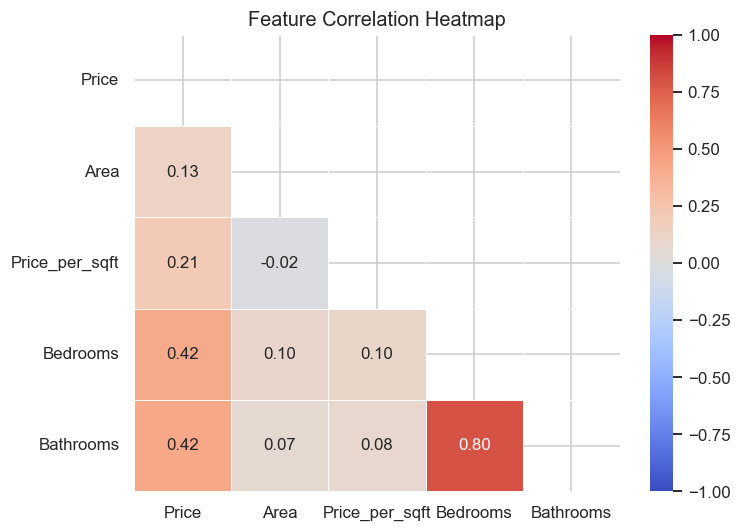

In [21]:
# Chart 7: Correlation Heatmap
# Shows linear relationships between numeric features.
# mask=upper triangle removes the redundant mirror half.
# Log_Price is NOT included — it's a transformation of Price (correlation = ~1.0 by definition),
# which would just add a trivially bright column/row and mislead the reader.

corr_cols = ['Price', 'Area', 'Price_per_sqft', 'Bedrooms', 'Bathrooms']
corr_matrix = plot_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={'size': 11}, ax=ax)
ax.set_title('Feature Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Insights & Recommendations

### Key Findings

**1. Prices are log-normally distributed**
Raw price histograms are heavily skewed right. After log transformation, they follow a near-normal distribution — a pattern universal in real estate. This means percentage-based thinking is more useful than absolute price comparisons.

**2. City is the strongest price driver**
Islamabad and Lahore consistently show the highest median prices. Karachi has the highest listing volume but more moderate median prices, suggesting better affordability per sqft.

**3. Property type matters — Houses dominate listings**
Houses and Flats make up the bulk of listings. Commercial and Plot listings are fewer but often command higher price-per-sqft, reflecting premium demand.

**4. More bedrooms = higher price, but not linearly**
The jump from 3-bed to 4+-bed is the most significant price step. Studio/1-bed properties in premium cities can rival 2-bed properties in secondary cities.

**5. Area is the strongest numeric correlator with price**
From the heatmap, Area has the highest correlation with Price. Bathrooms and Bedrooms also positively correlate, but more weakly.

### Recommendations for Investors

| Strategy | Rationale |
|---|---|
| **Target Lahore/Islamabad for capital appreciation** | Highest median price; historically strong appreciation |
| **Target Karachi for rental yield** | High volume, moderate prices, strong rental demand |
| **Use price-per-sqft, not total price, to compare listings** | Total price is biased by size; per-sqft is location-fair |
| **Focus on 3-bed Standard-size (500–1500 sqft) properties** | Most liquid segment — easiest to resell |
| **Avoid mixing For Sale and For Rent in any price analysis** | They operate on completely different price scales |

## 8. Conclusion & Next Steps

### Summary of Learnings

This EDA of Zameen.com listings shows that Pakistan's real estate market is characterised by high price variance, geographic segmentation, and significant data quality challenges (messy price strings, inconsistent area units, missing values). The analysis confirmed that:

- **Location (city) is the dominant pricing factor**, followed by property area
- **Property type and bedroom count add secondary predictive value**
- **Log-transforming price** is essential before any statistical comparison or modelling
- **Data cleaning** (FuzzyWuzzy, regex parsing, IQR outlier handling) was critical to producing trustworthy results

### Next Steps

**Data Quality:**
- Include a `Description` text column for NLP-based feature extraction (e.g. "gated community", "servant quarter" keywords that add price premium)
- Add listing dates to enable time-series trend analysis

**Modelling:**
- Train a regression model (e.g. Gradient Boosting Regressor) on `Log_Price` using City, Area, Type, and Bedrooms as features
- Cross-validate by city to avoid geographic data leakage

**Stakeholder Tools:**
- Build a simple price estimator: City + Type + Area + Bedrooms → predicted price range
- Create a neighbourhood ranking table using median `Price_per_sqft` by Location